This ipynb file is made to add perturbations (gaussian noise) to the selected .wav files (with already Wiener filter)

In [12]:
# Standard libraries
from pathlib import Path
from scipy.io import wavfile
from scipy.signal import wiener
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
import shutil

# load data
DATA_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\TAME")
WIENER_INPUT_DIR = DATA_PATH / "wiener_filtered_audio_pain"
GAUSSIAN_OUTPUT_DIR = DATA_PATH / "wiener_gaussian_noise_perturbations_pain"

INTENSITY_OUTPUT_DIR = DATA_PATH / "wiener_intensity_perturbations"
INTENSITY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)





In [13]:
# Collect WAV files
wiener_audio_files = []

for root, dirs, files in os.walk(WIENER_INPUT_DIR):
    for file in files:
        if file.endswith(".wav"):
            wiener_audio_files.append(os.path.join(root, file))

print(f"Number of Wiener-filtered audio files: {len(wiener_audio_files)}")

Number of Wiener-filtered audio files: 1055


In [14]:
def load_wav_file(file_path):
    """
    Load a WAV file and return sample rate and signal.
    """
    sample_rate, signal = wavfile.read(file_path)
    return sample_rate, signal


def save_wav_file(file_path, sample_rate, signal):
    """
    Save a WAV file as int16.
    """
    signal = np.clip(signal, -32768, 32767)  # keep within 16-bit range
    signal = signal.astype(np.int16)
    wavfile.write(file_path, sample_rate, signal)


def add_gaussian_noise(signal, noise_std_fraction):
    """
    Add Gaussian noise to an audio signal.

    Parameters
    signal : np.ndarray
        Input audio signal.
    noise_std_fraction : float
        Fraction of the signal standard deviation used as noise standard deviation.

    Returns
    noisy_signal : np.ndarray
        Audio signal with added Gaussian noise.
    """
    signal = signal.astype(np.float32)

    # Standard deviation of the original signal
    signal_std = np.std(signal)

    # Standard deviation of the Gaussian noise
    noise_std = noise_std_fraction * signal_std

    # Generate Gaussian noise with mean 0 (random noise)
    noise = np.random.normal(loc=0.0, scale=noise_std, size=signal.shape)

    noisy_signal = signal + noise
    return noisy_signal


def make_perturbation_output_path(input_path, input_root, output_root, perturbation_name):
    """
    Save perturbed audio in:
    output_root / perturbation_name / PID / original_filename.wav
    """
    relative_path = os.path.relpath(input_path, input_root)
    output_path = os.path.join(output_root, perturbation_name, relative_path)

    output_dir = os.path.dirname(output_path)
    os.makedirs(output_dir, exist_ok=True)

    return output_path

In [15]:
perturbations = {
    "low_gaussian_noise": 0.005,  #0.5%
    "medium_gaussian_noise": 0.02,    #2%    
    "high_gaussian_noise": 0.05,   #5%  
    "very_high_gaussian_noise": 0.1 #10%      
}

In [16]:
# Save Gaussian noise perturbed files
processed_rows = []

for input_path in wiener_audio_files:
    try:
        sample_rate, signal = load_wav_file(input_path)

        for perturbation_name, noise_std_fraction in perturbations.items():
            noisy_signal = add_gaussian_noise(signal, noise_std_fraction)

            output_path = make_perturbation_output_path(
                input_path=input_path,
                input_root=WIENER_INPUT_DIR,
                output_root=GAUSSIAN_OUTPUT_DIR,
                perturbation_name=perturbation_name
            )

            save_wav_file(output_path, sample_rate, noisy_signal)

            participant_id = os.path.basename(os.path.dirname(input_path))
            filename = os.path.basename(input_path)

            processed_rows.append({
                "participant_id": participant_id,
                "filename": filename,
                "original_wiener_file_path": input_path,
                "perturbation": perturbation_name,
                "noise_std_fraction": noise_std_fraction,
                "perturbed_file_path": output_path
            })

    except Exception as e:
        print(f"Error processing {input_path}: {e}")

print("Finished processing Gaussian noise perturbations.")

Finished processing Gaussian noise perturbations.


In [17]:
#check of number of files is correct
expected_files_per_perturbation = len(wiener_audio_files)
for perturbation_name in perturbations.keys():
    perturbation_dir = GAUSSIAN_OUTPUT_DIR / perturbation_name
    if perturbation_dir.exists():
        num_files = sum(len(files) for _, _, files in os.walk(perturbation_dir))
        print(f"{perturbation_name}: {num_files} files (expected: {expected_files_per_perturbation})")
    else:
        print(f"{perturbation_name}: Directory does not exist.")

        

low_gaussian_noise: 1055 files (expected: 1055)
medium_gaussian_noise: 1055 files (expected: 1055)
high_gaussian_noise: 1055 files (expected: 1055)
very_high_gaussian_noise: 1055 files (expected: 1055)


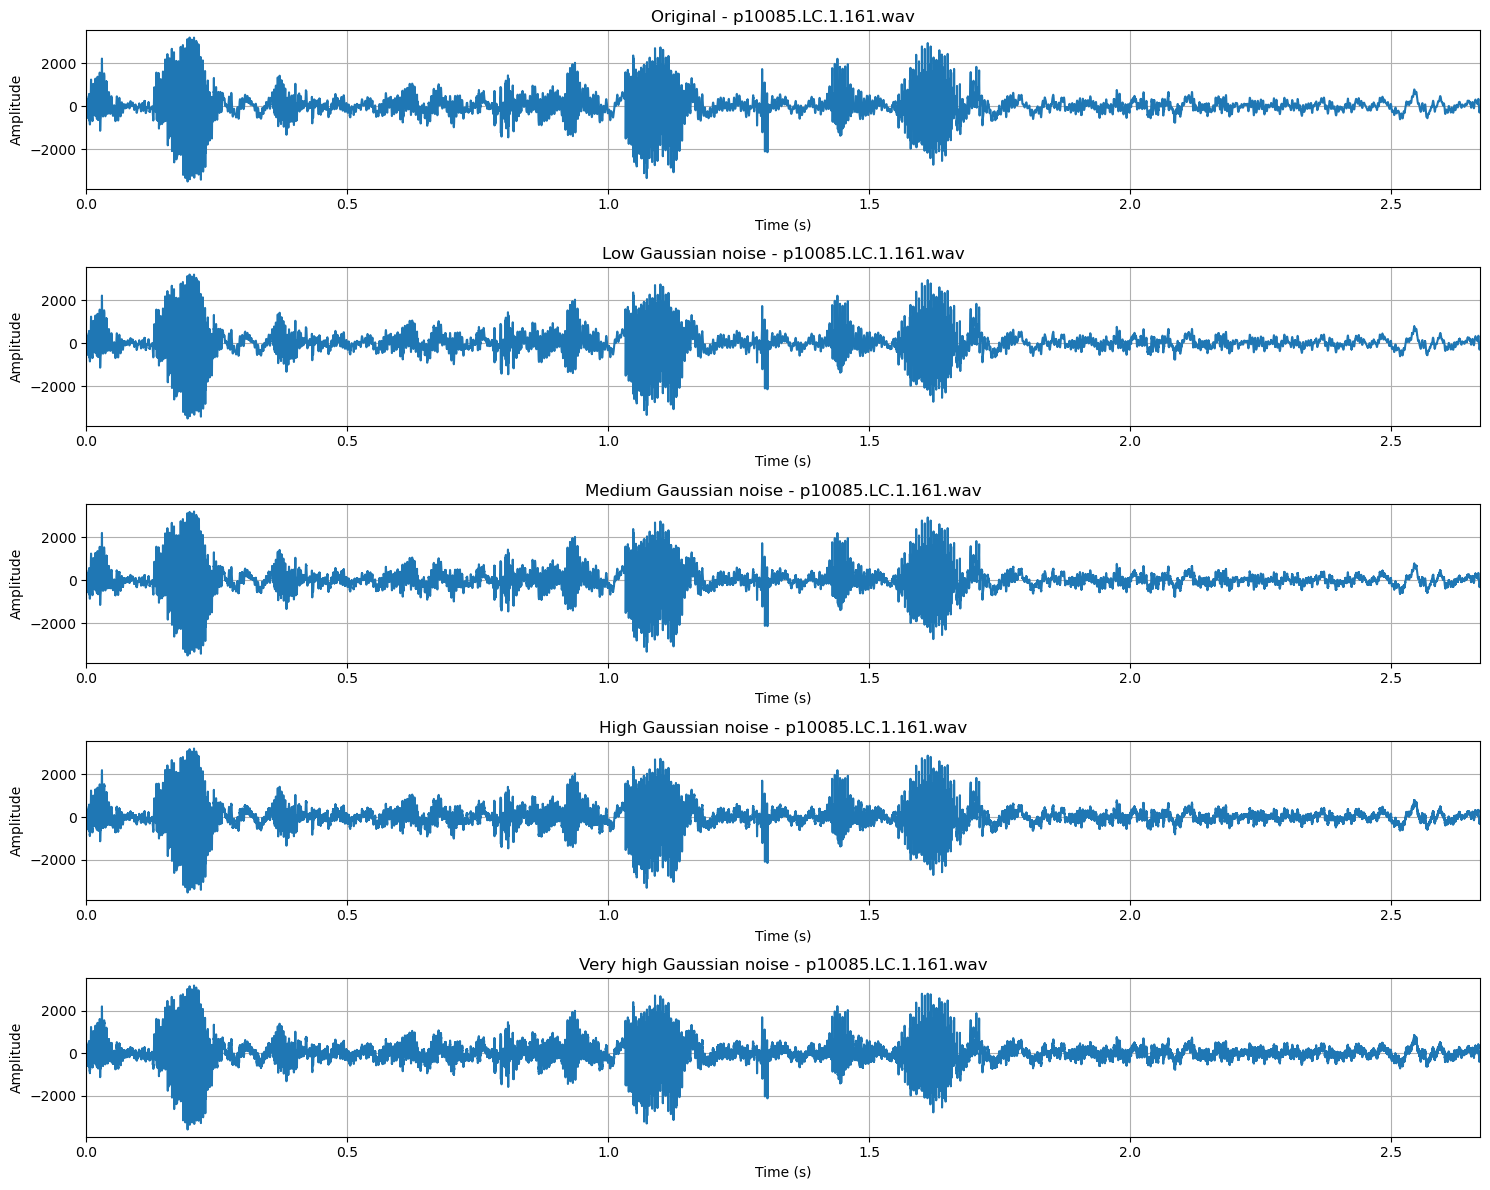

In [18]:
# which participant plot
participant_id = "p10085"
filename = "p10085.LC.1.161.wav"

original_file = os.path.join(WIENER_INPUT_DIR, participant_id, filename)

perturbed_files = {
    "Original": original_file,
    "Low Gaussian noise": os.path.join(GAUSSIAN_OUTPUT_DIR, "low_gaussian_noise", participant_id, filename),
    "Medium Gaussian noise": os.path.join(GAUSSIAN_OUTPUT_DIR, "medium_gaussian_noise", participant_id, filename),
    "High Gaussian noise": os.path.join(GAUSSIAN_OUTPUT_DIR, "high_gaussian_noise", participant_id, filename),
    "Very high Gaussian noise": os.path.join(GAUSSIAN_OUTPUT_DIR, "very_high_gaussian_noise", participant_id, filename),
}

# Plot
plt.figure(figsize=(15, 12))

for i, (label, file_path) in enumerate(perturbed_files.items(), 1):
    sample_rate, signal = load_wav_file(file_path)
    signal = signal.astype(np.float32)

    time = np.arange(len(signal)) / sample_rate

    plt.subplot(5, 1, i)
    plt.plot(time, signal)
    plt.title(f"{label} - {filename}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.xlim(0, min(3, time[-1]))  # first 3 seconds
    plt.grid(True)

plt.tight_layout()
plt.show()

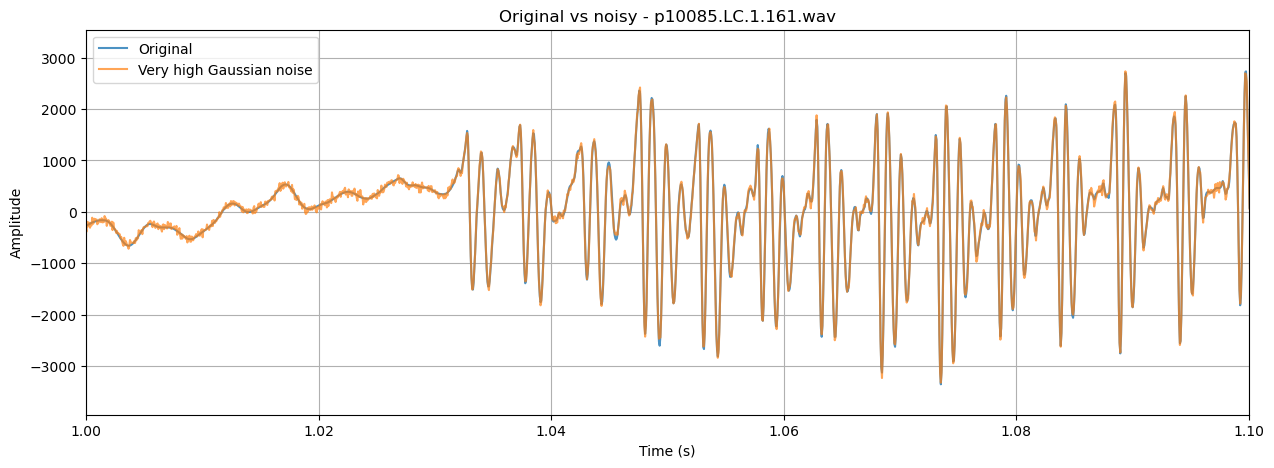

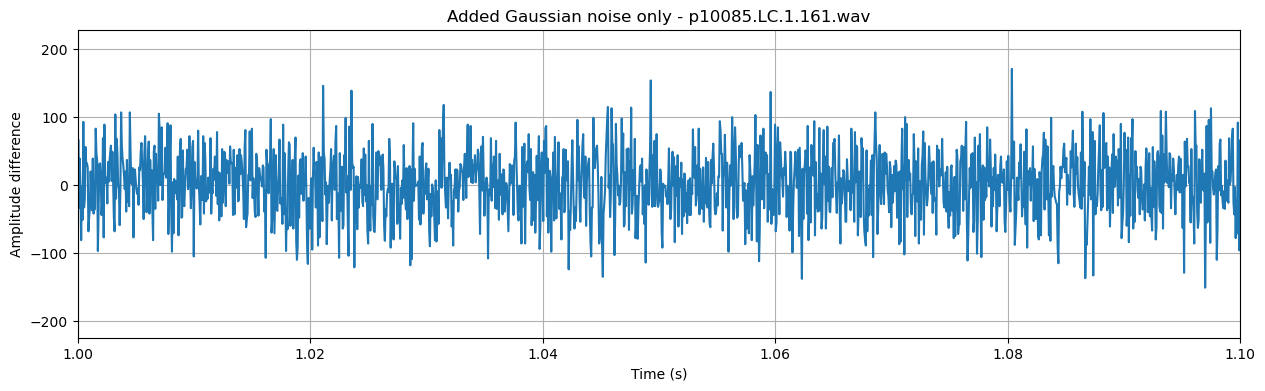

In [19]:
participant_id = "p10085"
filename = "p10085.LC.1.161.wav"

original_file = os.path.join(WIENER_INPUT_DIR, participant_id, filename)
noisy_file = os.path.join(GAUSSIAN_OUTPUT_DIR, "very_high_gaussian_noise", participant_id, filename)

sr_orig, signal_orig = load_wav_file(original_file)
sr_noisy, signal_noisy = load_wav_file(noisy_file)

signal_orig = signal_orig.astype(np.float32)
signal_noisy = signal_noisy.astype(np.float32)

time = np.arange(len(signal_orig)) / sr_orig

plt.figure(figsize=(15, 5))
plt.plot(time, signal_orig, label="Original", alpha=0.8)
plt.plot(time, signal_noisy, label="Very high Gaussian noise", alpha=0.7)
plt.xlim(1.0, 1.1)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Original vs noisy - {filename}")
plt.legend()
plt.grid(True)
plt.show()

difference = signal_noisy - signal_orig

plt.figure(figsize=(15, 4))
plt.plot(time, difference)
plt.xlim(1.0, 1.1)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude difference")
plt.title(f"Added Gaussian noise only - {filename}")
plt.grid(True)
plt.show()

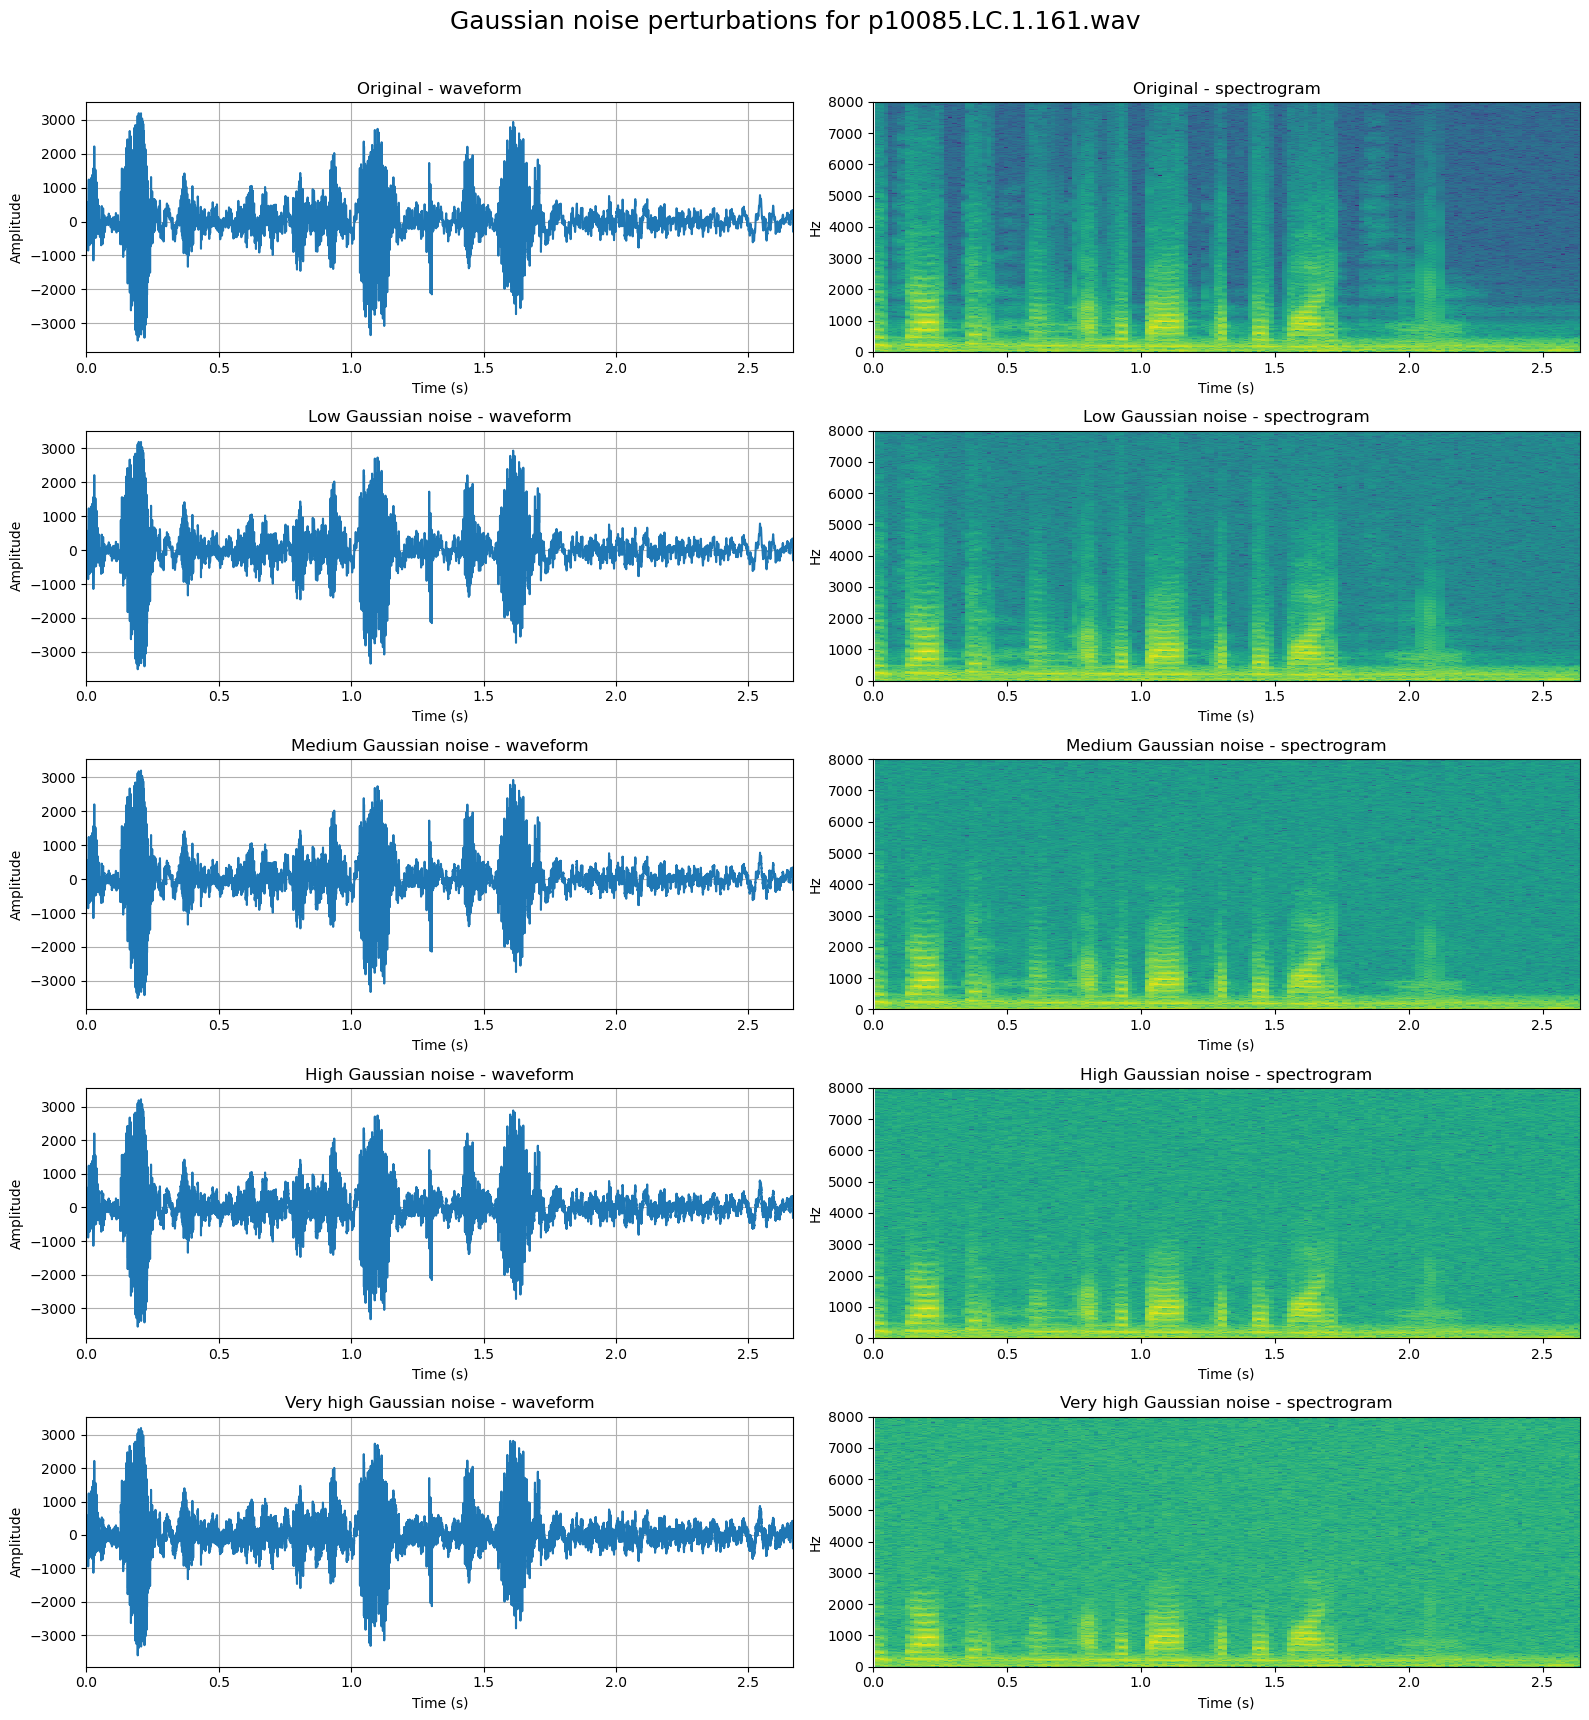

In [20]:
from scipy.signal import spectrogram
import matplotlib.pyplot as plt
import numpy as np
import os

# which participant plot
participant_id = "p10085"
filename = "p10085.LC.1.161.wav"

original_file = os.path.join(WIENER_INPUT_DIR, participant_id, filename)

perturbed_files = {
    "Original": original_file,
    "Low Gaussian noise": os.path.join(GAUSSIAN_OUTPUT_DIR, "low_gaussian_noise", participant_id, filename),
    "Medium Gaussian noise": os.path.join(GAUSSIAN_OUTPUT_DIR, "medium_gaussian_noise", participant_id, filename),
    "High Gaussian noise": os.path.join(GAUSSIAN_OUTPUT_DIR, "high_gaussian_noise", participant_id, filename),
    "Very high Gaussian noise": os.path.join(GAUSSIAN_OUTPUT_DIR, "very_high_gaussian_noise", participant_id, filename),
}

def plot_participant_gaussian_comparison(perturbed_files, max_time=3, max_freq=8000):
    """
    Plot for one participant/file:
    left = waveform
    right = spectrogram
    rows = different perturbation levels
    """
    n_rows = len(perturbed_files)
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 3.5 * n_rows))
    fig.suptitle("Gaussian noise perturbations for p10085.LC.1.161.wav", fontsize=18)

    # Eerst alle spectrogrammen inladen zodat dezelfde color scale gebruikt wordt
    spectrogram_data = []
    global_vmin = np.inf
    global_vmax = -np.inf

    for label, file_path in perturbed_files.items():
        sample_rate, signal = load_wav_file(file_path)
        signal = signal.astype(np.float32)

        f, t_spec, Sxx = spectrogram(
            signal,
            fs=sample_rate,
            nperseg=512,
            noverlap=256,
            scaling="spectrum",
            mode="magnitude"
        )

        freq_mask = f <= max_freq
        Sxx_log = 10 * np.log10(Sxx[freq_mask] + 1e-10)

        global_vmin = min(global_vmin, Sxx_log.min())
        global_vmax = max(global_vmax, Sxx_log.max())

        spectrogram_data.append((label, file_path, sample_rate, signal, f[freq_mask], t_spec, Sxx_log))

    # Nu plotten
    for i, (label, file_path, sample_rate, signal, f_plot, t_spec, Sxx_log) in enumerate(spectrogram_data):
        time = np.arange(len(signal)) / sample_rate

        # Waveform
        axes[i, 0].plot(time, signal)
        axes[i, 0].set_title(f"{label} - waveform")
        axes[i, 0].set_xlabel("Time (s)")
        axes[i, 0].set_ylabel("Amplitude")
        axes[i, 0].set_xlim(0, min(max_time, time[-1]))
        axes[i, 0].grid(True)

        # Spectrogram
        im = axes[i, 1].pcolormesh(
            t_spec,
            f_plot,
            Sxx_log,
            shading="auto",
            vmin=global_vmin,
            vmax=global_vmax
        )
        axes[i, 1].set_title(f"{label} - spectrogram")
        axes[i, 1].set_xlabel("Time (s)")
        axes[i, 1].set_ylabel("Hz")
        axes[i, 1].set_xlim(0, min(max_time, t_spec[-1]))
        axes[i, 1].set_ylim(0, max_freq)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# Run
plot_participant_gaussian_comparison(perturbed_files, max_time=3, max_freq=8000)

Gaussian noise on Original files 

In [29]:
# Standard libraries
from pathlib import Path
from scipy.io import wavfile
from scipy.signal import wiener
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
import shutil

# load data
DATA_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\TAME")
ORIGINAL_INPUT_DIR = DATA_PATH / "selected_original_audio_pain"
ORIGINAL_GAUSSIAN_OUTPUT_DIR = DATA_PATH / "original_gaussian_noise_perturbations_pain"

INTENSITY_OUTPUT_DIR = DATA_PATH / "original_intensity_perturbations"
INTENSITY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [30]:
# Collect WAV files
original_audio_files = []

for root, dirs, files in os.walk(ORIGINAL_INPUT_DIR):
    for file in files:
        if file.endswith(".wav"):
            original_audio_files.append(os.path.join(root, file))

print(f"Number of original audio files: {len(wiener_audio_files)}")

Number of original audio files: 1055


In [31]:
def load_wav_file(file_path):
    """
    Load a WAV file and return sample rate and signal.
    """
    sample_rate, signal = wavfile.read(file_path)
    return sample_rate, signal


def save_wav_file(file_path, sample_rate, signal):
    """
    Save a WAV file as int16.
    """
    signal = np.clip(signal, -32768, 32767)  # keep within 16-bit range
    signal = signal.astype(np.int16)
    wavfile.write(file_path, sample_rate, signal)


def add_gaussian_noise(signal, noise_std_fraction):
    """
    Add Gaussian noise to an audio signal.

    Parameters
    signal : np.ndarray
        Input audio signal.
    noise_std_fraction : float
        Fraction of the signal standard deviation used as noise standard deviation.

    Returns
    noisy_signal : np.ndarray
        Audio signal with added Gaussian noise.
    """
    signal = signal.astype(np.float32)

    # Standard deviation of the original signal
    signal_std = np.std(signal)

    # Standard deviation of the Gaussian noise
    noise_std = noise_std_fraction * signal_std

    # Generate Gaussian noise with mean 0 (random noise)
    noise = np.random.normal(loc=0.0, scale=noise_std, size=signal.shape)

    noisy_signal = signal + noise
    return noisy_signal


def make_perturbation_output_path(input_path, input_root, output_root, perturbation_name):
    """
    Save perturbed audio in:
    output_root / perturbation_name / PID / original_filename.wav
    """
    relative_path = os.path.relpath(input_path, input_root)
    output_path = os.path.join(output_root, perturbation_name, relative_path)

    output_dir = os.path.dirname(output_path)
    os.makedirs(output_dir, exist_ok=True)

    return output_path

In [32]:
perturbations = {
    "low_gaussian_noise": 0.005,  #0.5%
    "medium_gaussian_noise": 0.02,    #2%    
    "high_gaussian_noise": 0.05,   #5%  
    "very_high_gaussian_noise": 0.1 #10%      
}

In [33]:
# Save Gaussian noise perturbed files
processed_rows = []

for input_path in original_audio_files:
    try:
        sample_rate, signal = load_wav_file(input_path)

        for perturbation_name, noise_std_fraction in perturbations.items():
            noisy_signal = add_gaussian_noise(signal, noise_std_fraction)

            output_path = make_perturbation_output_path(
                input_path=input_path,
                input_root=ORIGINAL_INPUT_DIR,
                output_root=ORIGINAL_GAUSSIAN_OUTPUT_DIR,
                perturbation_name=perturbation_name
            )

            save_wav_file(output_path, sample_rate, noisy_signal)

            participant_id = os.path.basename(os.path.dirname(input_path))
            filename = os.path.basename(input_path)

            processed_rows.append({
                "participant_id": participant_id,
                "filename": filename,
                "original_original_file_path": input_path,
                "perturbation": perturbation_name,
                "noise_std_fraction": noise_std_fraction,
                "perturbed_file_path": output_path
            })

    except Exception as e:
        print(f"Error processing {input_path}: {e}")

print("Finished processing Gaussian noise perturbations.")

Finished processing Gaussian noise perturbations.


In [34]:
#check of number of files is correct
expected_files_per_perturbation = len(original_audio_files)
for perturbation_name in perturbations.keys():
    perturbation_dir = GAUSSIAN_OUTPUT_DIR / perturbation_name
    if perturbation_dir.exists():
        num_files = sum(len(files) for _, _, files in os.walk(perturbation_dir))
        print(f"{perturbation_name}: {num_files} files (expected: {expected_files_per_perturbation})")
    else:
        print(f"{perturbation_name}: Directory does not exist.")

        

low_gaussian_noise: 1055 files (expected: 1055)
medium_gaussian_noise: 1055 files (expected: 1055)
high_gaussian_noise: 1055 files (expected: 1055)
very_high_gaussian_noise: 1055 files (expected: 1055)


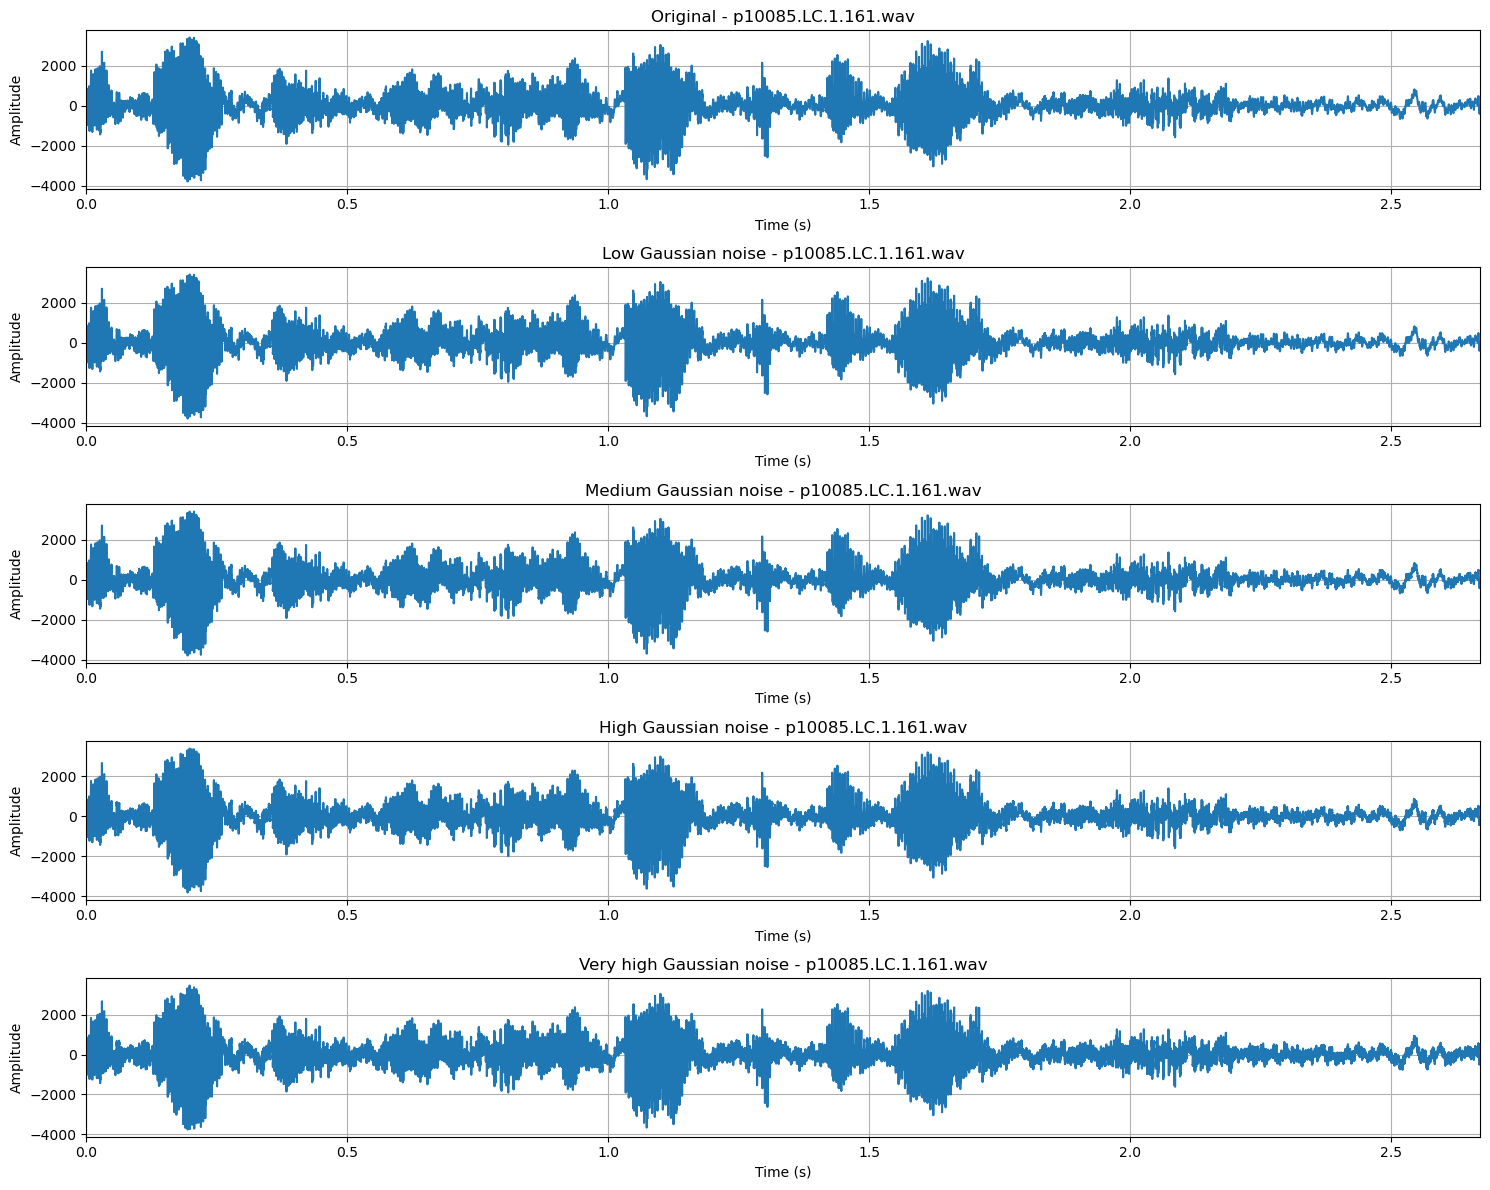

In [ ]:
# which participant plot
participant_id = "p10085"
filename = "p10085.LC.1.161.wav"

original_file = os.path.join(ORIGINAL_INPUT_DIR, participant_id, filename)

perturbed_files = {
    "Original": original_file,
    "Low Gaussian noise": os.path.join(ORIGINAL_GAUSSIAN_OUTPUT_DIR, "low_gaussian_noise", participant_id, filename),
    "Medium Gaussian noise": os.path.join(ORIGINAL_GAUSSIAN_OUTPUT_DIR, "medium_gaussian_noise", participant_id, filename),
    "High Gaussian noise": os.path.join(ORIGINAL_GAUSSIAN_OUTPUT_DIR, "high_gaussian_noise", participant_id, filename),
    "Very high Gaussian noise": os.path.join(ORIGINAL_GAUSSIAN_OUTPUT_DIR, "very_high_gaussian_noise", participant_id, filename),
}

# Plot
plt.figure(figsize=(15, 12))

for i, (label, file_path) in enumerate(perturbed_files.items(), 1):
    sample_rate, signal = load_wav_file(file_path)
    signal = signal.astype(np.float32)

    time = np.arange(len(signal)) / sample_rate

    plt.subplot(5, 1, i)
    plt.plot(time, signal)
    plt.title(f"{label} - {filename}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.xlim(0, min(3, time[-1]))  
    plt.grid(True)

plt.tight_layout()
plt.show()